In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import MetaTrader5 as mt5
import os
from dotenv import load_dotenv
import datetime as dt

load_dotenv()


True

In [10]:
password = os.getenv('password')
mt5.initialize()
if not mt5.login(login=31829987, password=password, server="Deriv-Demo"):
    print("Login failed")
print('Logged in...')


Logged in...


In [11]:
TIMEFRAME = mt5.TIMEFRAME_M15

# n = 5
start = dt.datetime(2025, 1, 1)
# end = dt.datetime(2026, 3, 28)
end = dt.datetime.now()
df1 = pd.DataFrame(mt5.copy_rates_range('GBPUSD', TIMEFRAME, start, end))
df2 = pd.DataFrame(mt5.copy_rates_range('EURGBP', TIMEFRAME, start, end))
df3 = pd.DataFrame(mt5.copy_rates_range('GBPCAD', TIMEFRAME, start, end))
df4 = pd.DataFrame(mt5.copy_rates_range('GBPJPY', TIMEFRAME, start, end))
df5 = pd.DataFrame(mt5.copy_rates_range('GBPCHF', TIMEFRAME, start, end))
df6 = pd.DataFrame(mt5.copy_rates_range('GBPNZD', TIMEFRAME, start, end))
df7 = pd.DataFrame(mt5.copy_rates_range('GBPAUD', TIMEFRAME, start, end))



In [12]:
LOOKBACK = 300
PAIR = "EURCHF"
def create_index():
    symbol_names = {
        "df1": "EURUSD",
        "df2": "EURGBP",
        "df3": "EURCAD",
        "df4": "EURJPY",
        "df5": "EURCHF",
        "df6": "EURNZD",
        "df7": "EURAUD",
    }

    frames = []
    for df_name, symbol in symbol_names.items():
        df = globals()[df_name][["time", "open"]].copy()
        df["time"] = pd.to_datetime(df["time"], unit="s")
        df = df.rename(columns={"open": f"{symbol}"})
        frames.append(df)

    EXY = frames[0]
    for frame in frames[1:]:
        EXY = EXY.merge(frame, on="time", how="outer")

    EXY = EXY.sort_values("time").reset_index(drop=True)
    EXY.head()

    rate_cols = ["EURUSD", "EURCAD", "EURJPY", "EURCHF", "EURNZD", "EURAUD", "EURGBP"]

    # Ensure all forex rates are numeric before log operation
    EXY[rate_cols] = EXY[rate_cols].apply(pd.to_numeric, errors="coerce")

    # Remove invalid rows before index calculation
    EXY = EXY.dropna(subset=rate_cols).reset_index(drop=True)

    rate_matrix = EXY[rate_cols].astype(float)
    EXY["EUR_Index"] = np.exp(np.log(rate_matrix).mean(axis=1))

    EXY = EXY.dropna().reset_index(drop=True)

    return EXY.iloc[-LOOKBACK:]

def GXY_log_returns(df):
    df["EUR_Index"] = pd.to_numeric(df["EUR_Index"], errors="coerce")
    df["EUR_Index_Returns"] = np.log(df["EUR_Index"].astype(float) / df["EUR_Index"].shift(1).astype(float))
    df = df.dropna().reset_index(drop=True)
    return df

def pair_log_returns(df, pair):
    df[pair] = pd.to_numeric(df[pair], errors="coerce")
    df[f"{pair}_Returns"] = np.log(df[pair].astype(float) / df[pair].shift(1).astype(float))
    df = df.dropna().reset_index(drop=True)
    return df

# def regression(df, pair):
#     X = df.GBP_Index_Returns.values
#     y = df[f"{pair}_Returns"].values
#     X = X.reshape(-1, 1)
#     model = sk.linear_model.LinearRegression()
#     model.fit(X, y)
#     y_pred = model.predict(X)
#     r2 = sk.metrics.r2_score(y, y_pred)

#     coef = model.coef_[0]
#     intercept = model.intercept_

#     print(F'Coefficient: {coef}')
#     print(f'Intercept: {intercept}')
#     print(f'R-squared: {r2}')

#     plt.figure()
#     plt.scatter(X, y)

#     return df, coef, intercept

def regression(df, pair, window=50):
    # Calculate inputs
    y = df[f"{pair}_Returns"]
    X = df["EUR_Index_Returns"]
    
    # Calculate rolling metrics
    rolling_cov = y.rolling(window).cov(X)
    rolling_var_x = X.rolling(window).var()
    
    df['beta'] = rolling_cov / rolling_var_x
    df['intercept'] = y.rolling(window).mean() - (df['beta'] * X.rolling(window).mean())
    
    # Calculate y_pred and Residuals BEFORE dropping NaNs
    df['y_pred'] = (df['beta'] * X) + df['intercept']
    df['Residuals'] = y - df['y_pred']
    
    # Drop the initial 'window' size of rows where rolling hasn't started
    df = df.dropna().reset_index(drop=True)
    
    # CRITICAL: Now 'y' must be taken from the cleaned dataframe to match length
    y_aligned = df[f"{pair}_Returns"]
    y_pred_aligned = df['y_pred']
    
    # Calculate R-squared on the aligned data
    r2 = sk.metrics.r2_score(y_aligned, y_pred_aligned)

    print(f'Coefficient (Latest): {df["beta"].iloc[-1]}')
    print(f'Intercept (Latest): {df["intercept"].iloc[-1]}')
    print(f'R-squared (Global on Rolling): {r2}')
    # Add this inside your regression function to get a live 'Quality' metric
    df['Rolling_R2'] = (df[f"{pair}_Returns"].rolling(window).corr(df["EUR_Index_Returns"]))**2
    print(f'R-squared (Rolling): {df["Rolling_R2"].iloc[-1]}')

    plt.figure()
    plt.scatter(X, y)

    plt.figure()
    plt.scatter(df.y_pred, df.Residuals)
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')

    return df, df.beta, df.intercept

# def test_linearity(df, coef, intercept, pair, features='GBP_Index_Returns'):

#     df['Predictions'] = (coef * df[features]) + intercept
#     df['Residuals'] = df.Predictions - df[f"{pair}_Returns"]
#     plt.figure()
#     plt.scatter(df.Predictions, df.Residuals)
#     plt.xlabel('Predicted Values')
#     plt.ylabel('Residuals')
#     return df

def calculate_halflife(residuals):
    """
    Calculates the half-life of mean reversion using an Ornstein-Uhlenbeck process.
    """
    # y(t) - y(t-1)
    res_diff = residuals.diff()
    # y(t-1)
    res_lag = residuals.shift(1)
    
    # Create a DataFrame to drop NaNs and align data
    df_reg = pd.DataFrame({'res_lag': res_lag, 'res_diff': res_diff}).dropna()
    
    # Prepare X and y for linear regression
    X = df_reg[['res_lag']].values
    y = df_reg['res_diff'].values
    
    # Run the linear regression
    model = sk.linear_model.LinearRegression()
    model.fit(X, y)
    
    # Get the slope (lambda), which is the speed of mean reversion
    lam = model.coef_[0]
    
    # Calculate half-life
    if lam < 0:
        halflife = -np.log(2) / lam
    else:
        halflife = np.inf # The series is not mean-reverting
        
    print(f'Speed of mean reversion (lambda): {lam}')
    print(f'Half-life: {halflife}')
    
    return halflife





def std_from_residuals(residuals, is_sample=True):
    """
    Calculates the standard deviation from a pre-calculated array of residuals.
    
    Parameters:
    residuals (array-like): The difference between actual and predicted values.
    is_sample (bool): Use True for sample standard deviation (Bessel's correction, ddof=1), 
                      False for population standard deviation (ddof=0). Default is True.
                      
    Returns:
    float: Standard deviation of residuals.
    """
    ddof = 1 if is_sample else 0
    return np.std(residuals, ddof=ddof)

import matplotlib.pyplot as plt

def plot_residuals_with_std(df, residuals, std_dev):
    """
    Plots the residuals over time, layering standard deviation bands.
    
    Parameters:
    df (pandas.DataFrame): The DataFrame containing the data.
    residuals (array-like or pandas.Series): The residual values.
    std_dev (float): The calculated standard deviation.
    """
    plt.figure(figsize=(12, 6))

    if isinstance(residuals, pd.Series):
        x = residuals.index
        # x = df.time
        y = residuals.astype(float)
    else:
        y = np.asarray(residuals, dtype=float)
        x = np.arange(len(y))
        # x = df.time

    # Plot the residuals line explicitly with time index as x
    plt.plot(x, y, label='Residuals', color='royalblue', alpha=0.8, linewidth=1.5)

    # Plot the Equilibrium/Mean line (assuming a central mean centered at 0)
    plt.axhline(0, color='black', linestyle='-', linewidth=1.5, label='Mean (0)')
    
    # Plot +/- 1 Standard Deviation bands
    plt.axhline(std_dev, color='darkorange', linestyle='--', alpha=0.8, label='+1 Std Dev')
    plt.axhline(-std_dev, color='darkorange', linestyle='--', alpha=0.8, label='-1 Std Dev')
    
    # Plot +/- 2 Standard Deviation bands (optional, often used for entry/exit signals)
    plt.axhline(2 * std_dev, color='red', linestyle=':', alpha=0.6, label='+2 Std Dev')
    plt.axhline(-2 * std_dev, color='green', linestyle=':', alpha=0.6, label='-2 Std Dev')
    
    # Add title and labels
    plt.title('Residuals and Standard Deviation Bands for Mean Reversion')
    plt.xlabel('Time Index')
    plt.ylabel('Spread / Residual Value')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

import pandas as pd
import matplotlib.pyplot as plt

def calculate_rolling_zscore(series, window):
    """
    Calculates the rolling Z-Score of a Pandas Series.
    
    Parameters:
    series (pd.Series): The residual values.
    window (int): The lookback period (e.g., your half-life value).
    
    Returns:
    pd.Series: The rolling Z-Score.
    """
    # Ensure the input is a Pandas Series for the .rolling() method
    if not isinstance(series, pd.Series):
        series = pd.Series(series)
        
    rolling_mean = series.rolling(window=window).mean()
    rolling_std = series.rolling(window=window).std()
    
    # Z-Score formula: (Value - Rolling Mean) / Rolling Std
    zscore = (series - rolling_mean) / rolling_std
    
    return zscore

def plot_rolling_zscore(df, zscore):
    """
    Plots the rolling Z-Score with typical entry/exit threshold bands.
    """
    plt.figure(figsize=(12, 6))
    
    # Plot the Z-Score
    plt.plot(df.time, zscore, label='Rolling Z-Score', color='purple', alpha=0.8)
    
    # Plot the 0 Mean line
    plt.axhline(0, color='black', linestyle='-', linewidth=1.5, label='Mean Z-Score (0)')
    
    # Plot standard threshold areas (commonly used in statistical arbitrage)
    plt.axhline(2, color='red', linestyle='--', alpha=0.7, label='Short Entry (+2)')
    plt.axhline(1, color='lightcoral', linestyle=':', alpha=0.7, label='Short Exit (+1)')
    
    plt.axhline(-2, color='green', linestyle='--', alpha=0.7, label='Long Entry (-2)')
    plt.axhline(-1, color='lightgreen', linestyle=':', alpha=0.7, label='Long Exit (-1)')
    
    plt.title('Rolling Z-Score of Residuals')
    plt.xlabel('Time Index')
    plt.ylabel('Z-Score')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

import plotly.graph_objects as go

def _r2_segments(index, r2, thresh):
    segs = []
    start = None
    for t, v in zip(index, r2):
        if v and start is None:
            start = t
        elif not v and start is not None:
            segs.append((start, prev_t))
            start = None
        prev_t = t
    if start is not None:
        segs.append((start, prev_t))
    return segs


def plot_zscore_with_confidence(zscore, rolling_r2):
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=zscore.index,
        y=zscore.values,
        mode='lines',
        name='Z-Score',
        line=dict(color='purple', width=2)
    ))

    thresholds = [
        (0.55, 'rgba(0, 128, 0, 0.1)', 'High Confidence > 0.55'),
        (0.65, 'rgba(0, 128, 0, 0.2)', 'High Confidence > 0.65'),
        (0.70, 'rgba(0, 128, 0, 0.3)', 'Very High Confidence > 0.70'),
    ]

    for thresh, color, label in thresholds:
        segs = _r2_segments(zscore.index, rolling_r2 > thresh, thresh)
        # segs returns list of (x0, x1) where the condition is true
        for x0, x1 in segs:
            fig.add_shape(
                type='rect',
                xref='x', yref='y',
                x0=x0, x1=x1,
                y0=-3, y1=3,
                fillcolor=color,
                line=dict(width=0),
                layer='below',
                name=label,
            )

    fig.add_hline(y=2, line=dict(color='red', dash='dash'), annotation_text='Upper Threshold (2)', annotation_position='top left')
    fig.add_hline(y=-2, line=dict(color='green', dash='dash'), annotation_text='Lower Threshold (-2)', annotation_position='bottom left')

    fig.update_layout(
        title='Z-Score with R-Squared Confidence Filter',
        xaxis_title='Time',
        yaxis_title='Z-Score',
        yaxis=dict(range=[-3.5, 3.5]),
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
    )

    fig.show()


Coefficient (Latest): 1.2165121674098833
Intercept (Latest): 9.063314986937267e-06
R-squared (Global on Rolling): 0.6842743777720068
R-squared (Rolling): 0.7328969592710379
Speed of mean reversion (lambda): -0.9637381877216452
Half-life: 0.7192276796653675


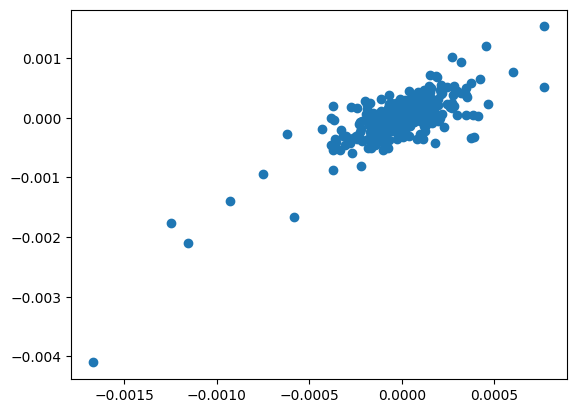

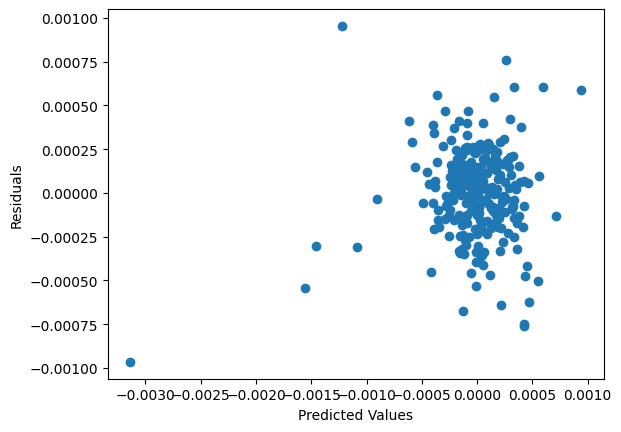

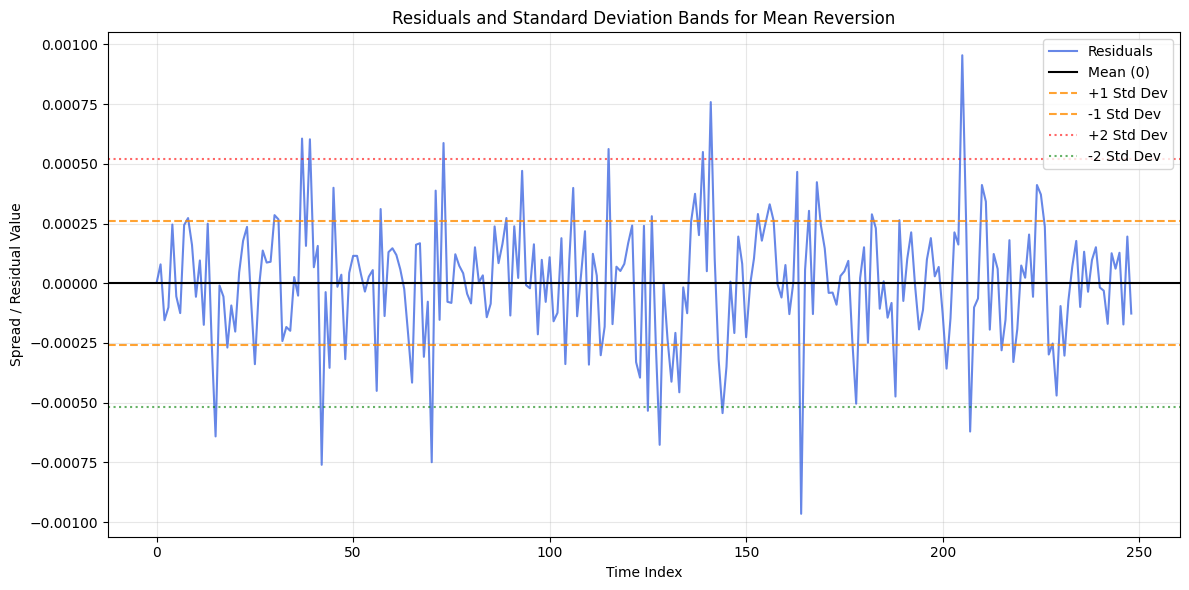

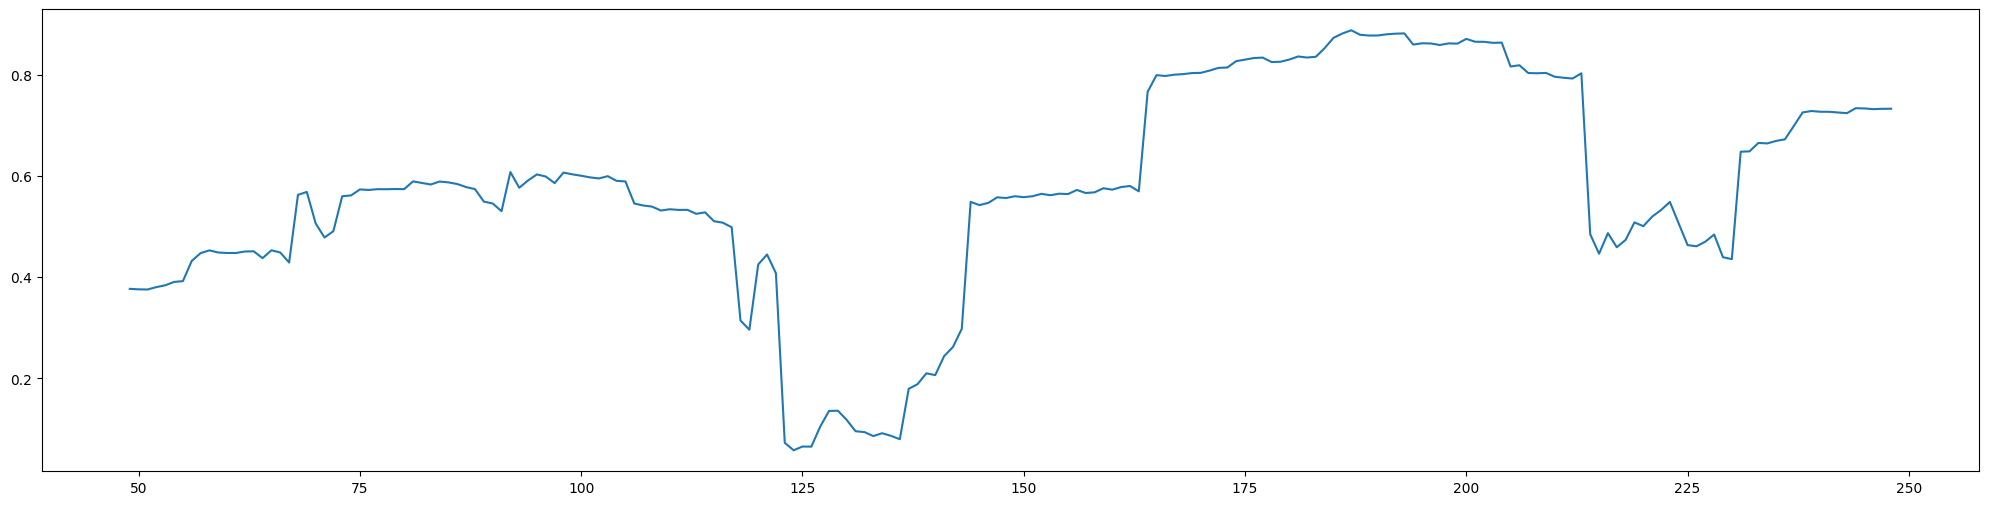

In [13]:
def main():
    df = create_index()
    df = GXY_log_returns(df)
    df = pair_log_returns(df, PAIR)
    df, coef, intercept = regression(df, PAIR)
    # df = test_linearity(df, coef, intercept, "PAIR")
    halflife = calculate_halflife(df['Residuals'])
    if not np.isfinite(halflife): halflife = 20
    std_dev = std_from_residuals(df['Residuals'])
    plot_residuals_with_std(df, df['Residuals'], std_dev)
    zscore = calculate_rolling_zscore(df['Residuals'], window=round(halflife * 20))
    plot_zscore_with_confidence(zscore, df['Rolling_R2'])
    plt.figure(figsize=(25, 6))
    plt.plot(df.Rolling_R2)

    return df

df = main()
# plt.figure(figsize=(12, 6))
# plt.plot(df["time"], df["EUR_Index_Returns"], label="EUR Index", color='blue')
# plt.plot(df["time"], df["EURUSD_Returns"], label="EURUSD", color='red')